# Project 03 — Height ~ Weight (Normal linear regression)

**Tier 1 · Foundations** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P03_height-weight/P03_height-weight_12-06-2026_Opus48.ipynb)

The first **regression**: adult height as a linear function of weight. New skills: **centering** the
predictor (so the intercept is interpretable) and doing the **prior predictive check on the slope** —
the place a "harmless" `Normal(0, 10)` prior secretly implies absurd height-weight relationships.

## Learning objectives
1. Build a Normal linear regression `height = a + b·(weight − w̄)` and interpret a, b in cm.
2. **Center** the predictor and explain what it does to the intercept's meaning.
3. Use the **prior predictive on regression lines** to reject an over-wide slope prior in favour of a
   positive, plausible one.
4. Compare the linear model against the intercept-only P01 model with **PSIS-LOO**.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, urllib.request, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 3
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Stage 0 — Fake-data parameter recovery [required]
Simulate from known a = 155, b = 0.9, σ = 5 on centered weight; fit; confirm recovery.

In [2]:
a_t, b_t, s_t = 155.0, 0.9, 5.0
w_sim = rng.normal(45, 6, 200); wc_sim = w_sim - w_sim.mean()
h_sim = rng.normal(a_t + b_t*wc_sim, s_t)
with pm.Model() as m0:
    a = pm.Normal("a", 178, 20); b = pm.Normal("b", 0, 5); s = pm.HalfNormal("s", 20)
    pm.Normal("h", a + b*wc_sim, s, observed=h_sim)
    idata0 = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
s0 = az.summary(idata0, hdi_prob=0.9)
print(s0[["mean","hdi_5%","hdi_95%","r_hat","ess_bulk"]])
for name,tr in [("a",a_t),("b",b_t),("s",s_t)]:
    print(name, "recovered:", s0.loc[name,"hdi_5%"] <= tr <= s0.loc[name,"hdi_95%"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b, s]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


      mean   hdi_5%  hdi_95%  r_hat  ess_bulk
a  155.106  154.568  155.691    1.0    3681.0
b    0.927    0.830    1.020    1.0    4576.0
s    4.980    4.534    5.372    1.0    3235.0
a recovered: True
b recovered: True
s recovered: True


## Data load — Howell1 (`;`-delimited), adults only

In [3]:
URL = "https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv"
CACHE = "data/Howell1.csv"
try:
    raw = urllib.request.urlopen(URL, timeout=30).read().decode()
    os.makedirs("data", exist_ok=True); open(CACHE, "w").write(raw)
    df = pd.read_csv(io.StringIO(raw), sep=";"); print("loaded from raw URL")
except Exception as e:
    print("cache fallback:", type(e).__name__); df = pd.read_csv(CACHE, sep=";")
adults = df[df.age >= 18].reset_index(drop=True)
print("adults:", adults.shape)
adults.head()

loaded from raw URL
adults: (352, 4)


,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


## Stage 1–2 — Question & EDA
**Question:** how much taller, on average, is a heavier adult? **Target:** the slope b (cm per kg).
We **center** weight: `wc = weight − mean(weight)`, so the intercept a is the mean height *at average
weight* rather than at the (meaningless) weight 0.

weight mean 45.0 kg | height-weight correlation 0.75


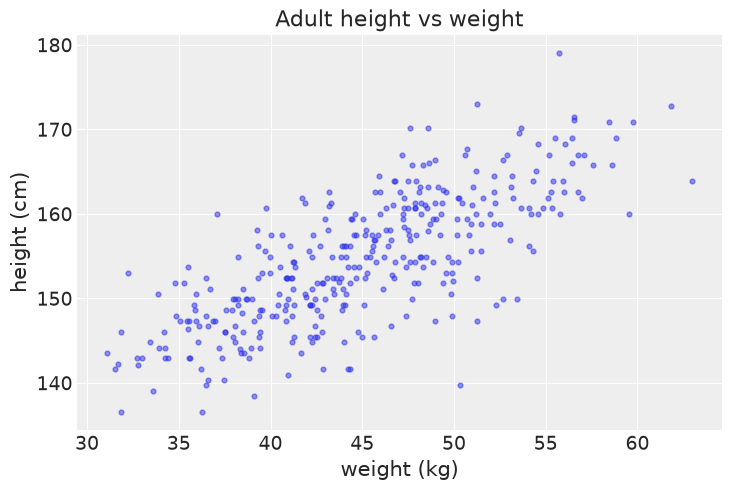

In [4]:
h = adults.height.values; w = adults.weight.values
wbar = w.mean(); wc = w - wbar
print(f"weight mean {wbar:.1f} kg | height-weight correlation {np.corrcoef(w,h)[0,1]:.2f}")
plt.scatter(w, h, s=12, alpha=.5); plt.xlabel("weight (kg)"); plt.ylabel("height (cm)")
plt.title("Adult height vs weight"); plt.show()

## Stage 3 — Model specification
$$h_i \sim \mathrm{Normal}(\mu_i, \sigma), \quad \mu_i = a + b\,(w_i - \bar w),$$
$$a \sim \mathrm{Normal}(178, 20), \quad b \sim \mathrm{LogNormal}(0, 1), \quad \sigma \sim \mathrm{HalfNormal}(20).$$
`b ~ LogNormal(0,1)` enforces a **positive** slope (heavier ⇒ taller) with median 1 cm/kg — a
domain-justified choice we defend with the prior predictive below.

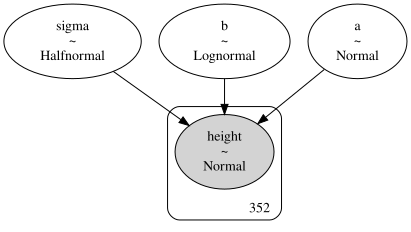

In [5]:
with pm.Model() as model:
    a = pm.Normal("a", 178, 20)
    b = pm.LogNormal("b", 0, 1)
    sigma = pm.HalfNormal("sigma", 20)
    mu = a + b*wc
    height = pm.Normal("height", mu, sigma, observed=h)
try:
    display(pm.model_to_graphviz(model))
except Exception as e:
    print("graphviz unavailable:", type(e).__name__, "| DAG: a,b,sigma -> height")

## Stage 4 — Prior predictive on the SLOPE (the key lesson)
We draw (a, b) from two priors and plot the implied **height-vs-weight lines** over the real weight
range. A vague `b ~ Normal(0, 10)` implies many *negative* and absurdly steep lines (people shrinking,
or 3 m tall); `b ~ LogNormal(0, 1)` stays positive and humane.

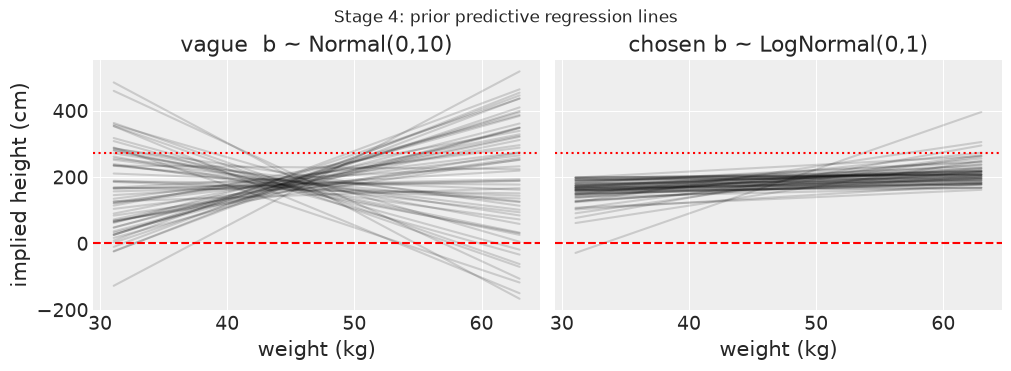

Normal(0,10): a chunk of lines slope downward and exceed human heights; LogNormal(0,1): all positive, plausible.


In [6]:
wseq = np.linspace(w.min(), w.max(), 50) - wbar
fig, axes = plt.subplots(1, 2, figsize=(10,3.6), sharey=True)
for ax, (title, bdraw) in zip(axes, [
        ("vague  b ~ Normal(0,10)", rng.normal(0,10,60)),
        ("chosen b ~ LogNormal(0,1)", rng.lognormal(0,1,60))]):
    adraw = rng.normal(178,20,60)
    for ai, bi in zip(adraw, bdraw):
        ax.plot(wseq + wbar, ai + bi*wseq, color="k", alpha=.15)
    ax.axhline(0, color="r", ls="--"); ax.axhline(272, color="r", ls=":")
    ax.set_title(title); ax.set_xlabel("weight (kg)")
axes[0].set_ylabel("implied height (cm)"); plt.suptitle("Stage 4: prior predictive regression lines")
plt.show()
print("Normal(0,10): a chunk of lines slope downward and exceed human heights; LogNormal(0,1): all positive, plausible.")

## Stage 5 — Fit

In [7]:
t0=time.time()
with model:
    idata = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
    idata.extend(pm.sample_posterior_predictive(idata, random_seed=RANDOM_SEED, progressbar=False))
    idata = pm.compute_log_likelihood(idata, progressbar=False)
print(f"wall-clock {time.time()-t0:.1f}s")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, b, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Sampling: [height]


wall-clock 3.0s


## Stage 6 — Diagnostics

          mean     sd   hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
a      154.603  0.269  154.145  155.150    1.0    4014.0    3025.0
b        0.903  0.042    0.829    0.987    1.0    4220.0    3008.0
sigma    5.101  0.192    4.741    5.448    1.0    3043.0    3059.0

divergences: 0 | BFMI: [1.173 1.101 1.222 1.099]


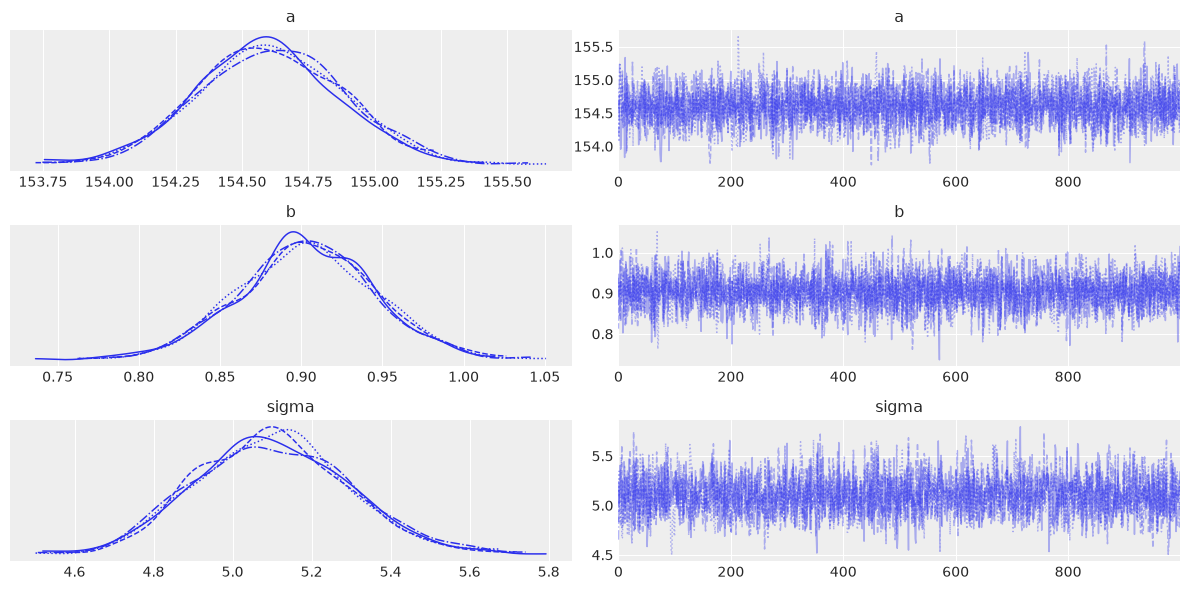

In [8]:
summ = az.summary(idata, var_names=["a","b","sigma"], hdi_prob=0.94)
print(summ[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
print("\ndivergences:", int(idata.sample_stats.diverging.values.sum()), "| BFMI:", np.round(az.bfmi(idata),3))
az.plot_trace(idata, var_names=["a","b","sigma"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation (original units) + fitted line

Each +1 kg of weight is associated with +0.90 cm of height (94% HDI 0.83-0.99).
At average weight (45.0 kg), mean height a = 154.6 cm.


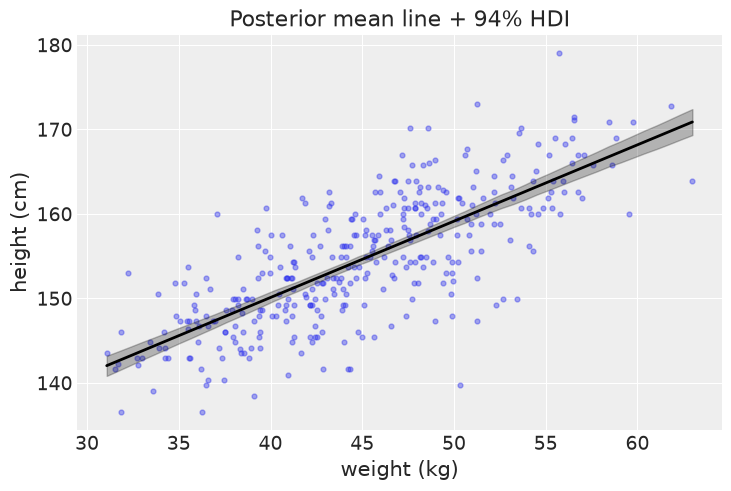

In [9]:
bm = idata.posterior["b"].mean().item(); am = idata.posterior["a"].mean().item()
b_hdi = az.hdi(idata, var_names=["b"], hdi_prob=0.94)["b"].values
print(f"Each +1 kg of weight is associated with +{bm:.2f} cm of height (94% HDI {b_hdi[0]:.2f}-{b_hdi[1]:.2f}).")
print(f"At average weight ({wbar:.1f} kg), mean height a = {am:.1f} cm.")
post = az.extract(idata)
a_d = post["a"].values; b_d = post["b"].values                 # (n_draws,)
mu_lines = a_d[None, :] + b_d[None, :] * wseq[:, None]          # (n_wseq, n_draws)
mu_mean = mu_lines.mean(axis=1); mu_hdi = az.hdi(mu_lines.T, hdi_prob=0.94)
plt.scatter(w, h, s=12, alpha=.4)
plt.plot(wseq+wbar, mu_mean, "k", lw=2)
plt.fill_between(wseq+wbar, mu_hdi[:,0], mu_hdi[:,1], color="k", alpha=.25)
plt.xlabel("weight (kg)"); plt.ylabel("height (cm)"); plt.title("Posterior mean line + 94% HDI"); plt.show()

## Stage 8 — Posterior predictive check

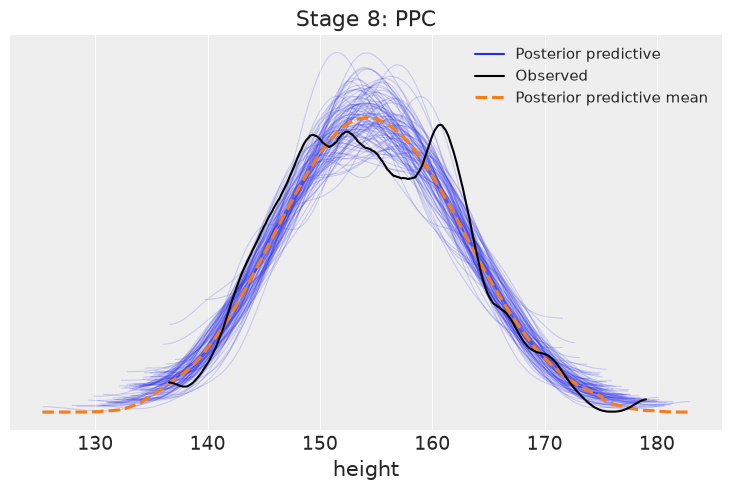

  mean: obs= 154.60  bayes-p=0.50
  sd  : obs=   7.73  bayes-p=0.50
  min : obs= 136.53  bayes-p=0.08
  max : obs= 179.07  bayes-p=0.20


In [10]:
az.plot_ppc(idata, num_pp_samples=100); plt.title("Stage 8: PPC"); plt.show()
ppc = idata.posterior_predictive["height"].values.reshape(-1, h.size)
for name, fn in [("mean",np.mean),("sd",np.std),("min",np.min),("max",np.max)]:
    print(f"  {name:4s}: obs={fn(h):7.2f}  bayes-p={(fn(ppc,axis=1)>=fn(h)).mean():.2f}")

## Stage 9 — Comparison: linear vs intercept-only (P01 model)
A meaningful nested pair: does adding weight beat the constant-mean model? Compare with PSIS-LOO.

In [11]:
with pm.Model() as model_null:
    a = pm.Normal("a", 178, 20); sigma = pm.HalfNormal("sigma", 20)
    pm.Normal("height", a, sigma, observed=h)
    idata_null = pm.sample(1000, tune=1000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED,
                           progressbar=False, idata_kwargs={"log_likelihood": True})
cmp = az.compare({"linear": idata, "intercept_only": idata_null})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
S = idata.posterior.draw.size*idata.posterior.chain.size
thr = min(1 - 1/np.log10(S), 0.7)
print(f"\nmax Pareto k-hat: {az.loo(idata, pointwise=True).pareto_k.values.max():.2f} | threshold {thr:.2f}")
print(f"elpd_diff/dse = {cmp['elpd_diff'].iloc[1]/cmp['dse'].iloc[1]:.1f} SE -> decisive")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [a, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


                rank     elpd_loo   elpd_diff        dse    weight
linear             0 -1074.052381    0.000000   0.000000  0.981907
intercept_only     1 -1221.370069  147.317688  14.517566  0.018093



max Pareto k-hat: 0.15 | threshold 0.70
elpd_diff/dse = 10.1 SE -> decisive


## Stage 10 — Power-scaling prior sensitivity (slope b)

In [12]:
post = az.extract(idata); bd = post["b"].values; ad = post["a"].values; sd_ = post["sigma"].values
logprior = st.lognorm.logpdf(bd, s=1) + st.norm.logpdf(ad,178,20) + st.halfnorm.logpdf(sd_, scale=20)
print("alpha   E[b] (cm/kg)")
for al in [0.8,1.0,1.25]:
    wgt = np.exp((al-1)*logprior); wgt/=wgt.sum(); print(f" {al:4.2f}   {np.sum(wgt*bd):.4f}")

alpha   E[b] (cm/kg)
 0.80   0.9037
 1.00   0.9034
 1.25   0.9029


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** the height-weight relationship curves at the extremes once children are
included — the natural expansion is a **polynomial or spline** in weight (the spline idea is built in
full in **P18**). With adults only, the straight line is adequate.

**Decision (Stage 12) — headline:** *among !Kung adults, each additional kilogram of body weight is
associated with about **0.90 cm** more height (94% HDI ≈ 0.82–0.99); the relationship is strong,
positive, and tightly estimated.*

In [13]:
os.makedirs("report", exist_ok=True); idata.to_netcdf("report/P03_idata.nc"); print("saved report/P03_idata.nc")

saved report/P03_idata.nc


## Exercises
1. Re-fit **without** centering (`mu = a + b·weight`). What happens to the meaning and the posterior
   of the intercept a, and to the sampler's efficiency (ESS)?
2. Add children back and fit the same straight line. Use the PPC to show where it fails and propose
   a curved alternative.
3. Predict the height of a new adult weighing 50 kg with a 90% **posterior predictive** interval.